In [1]:
import numpy as np
import pandas as pd
import re

from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Corpus
documents = [
    "Text analysis relies on numerical representations",
    "Vectors and matrices are core mathematical tools",
    "Large collections of text can be processed efficiently"
]

# 2. Vectorizador
vectorizer = CountVectorizer(stop_words="english")

# 3. Ajuste y transformación
X = vectorizer.fit_transform(documents)

# 4. Mostrar vocabulario ordenado
print("Vocabulario:")
vocab = dict(sorted(vectorizer.vocabulary_.items(), key=lambda x: x[1]))
print(vocab)

# 5. Mostrar matriz documento-término
print("Matriz (documentos × términos):")
print(X.toarray())

# 6. Mostrar términos en orden de columnas
print("Términos (columnas):")
print(vectorizer.get_feature_names_out())

Vocabulario:
{'analysis': 0, 'collections': 1, 'core': 2, 'efficiently': 3, 'large': 4, 'mathematical': 5, 'matrices': 6, 'numerical': 7, 'processed': 8, 'relies': 9, 'representations': 10, 'text': 11, 'tools': 12, 'vectors': 13}
Matriz (documentos × términos):
[[1 0 0 0 0 0 0 1 0 1 1 1 0 0]
 [0 0 1 0 0 1 1 0 0 0 0 0 1 1]
 [0 1 0 1 1 0 0 0 1 0 0 1 0 0]]
Términos (columnas):
['analysis' 'collections' 'core' 'efficiently' 'large' 'mathematical'
 'matrices' 'numerical' 'processed' 'relies' 'representations' 'text'
 'tools' 'vectors']


# Ejemplo

In [5]:
sentences = [
    "Data science connects statistics and computation",
    "Statistical models learn patterns from data",
    "Modern data analysis relies on computational tools"
]

In [17]:
corpus = pd.Series(sentences)
corpus

0     Data science connects statistics and computation
1          Statistical models learn patterns from data
2    Modern data analysis relies on computational t...
dtype: object

In [18]:
# Step 3a: Required packages
import nltk

# Ejecutar solo una vez (puedes comentar luego)
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import numpy as np
import pandas as pd

def clean_and_lemmatize(text):
    stop = set(stopwords.words("english"))
    lemmatizer = WordNetLemmatizer()
    
    tokens = re.sub(r"[^a-zA-Z]", " ", text).lower().split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop]
    
    return " ".join(tokens)

#Step 3c: Applying the preprocessing function to the corpus {.unlisted .unnumbered}
processed_corpus = corpus.apply(clean_and_lemmatize)
print(processed_corpus)

0       data science connects statistic computation
1              statistical model learn pattern data
2    modern data analysis relies computational tool
dtype: object


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nataliangaritaescolar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/nataliangaritaescolar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [19]:
print(processed_corpus)

0       data science connects statistic computation
1              statistical model learn pattern data
2    modern data analysis relies computational tool
dtype: object


In [20]:
len(processed_corpus)

3

In [22]:
vocabulary = sorted(set(
    word for sentence in processed_corpus for word in sentence.split()
))
vocabulary

['analysis',
 'computation',
 'computational',
 'connects',
 'data',
 'learn',
 'model',
 'modern',
 'pattern',
 'relies',
 'science',
 'statistic',
 'statistical',
 'tool']

In [ ]:
len(vocabulary)

14

In [24]:
token_index = {token: idx for idx, token in enumerate(vocabulary)}
token_index

{'analysis': 0,
 'computation': 1,
 'computational': 2,
 'connects': 3,
 'data': 4,
 'learn': 5,
 'model': 6,
 'modern': 7,
 'pattern': 8,
 'relies': 9,
 'science': 10,
 'statistic': 11,
 'statistical': 12,
 'tool': 13}

In [25]:
bow_matrix = np.zeros((len(processed_corpus), len(vocabulary)))
bow_matrix

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [26]:
(len(processed_corpus), len(vocabulary))

(3, 14)

In [27]:
for i, sentence in enumerate(processed_corpus):
    for token in sentence.split():
        bow_matrix[i, token_index[token]] += 1

In [28]:
print(bow_matrix)

[[0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0.]
 [1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1.]]


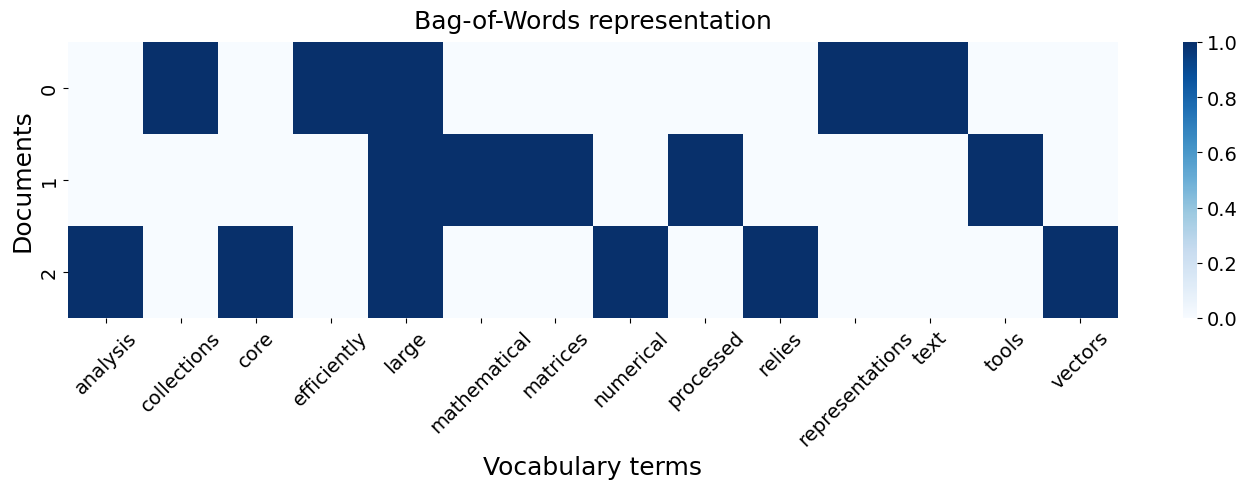

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Obtener términos
terms = vectorizer.get_feature_names_out()

# Asegurar formato correcto
if isinstance(bow_matrix, np.ndarray):
    X = bow_matrix
else:
    X = bow_matrix.toarray()

# Crear DataFrame
df_bow = pd.DataFrame(X, columns=terms)

# Gráfico
plt.figure(figsize=(14,5))
ax = sns.heatmap(df_bow, cmap="Blues", cbar=True)

# --- Title and axis labels ---
ax.set_title("Bag-of-Words representation", fontsize=18, pad=10)
ax.set_xlabel("Vocabulary terms", fontsize=18)
ax.set_ylabel("Documents", fontsize=18)

# --- Tick labels ---
ax.tick_params(axis="x", labelsize=14, rotation=45)
ax.tick_params(axis="y", labelsize=14)

# --- Colorbar font size ---
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()

# Unigramas, brigramas, trigrmas

In [33]:
vectorizer_ngram = CountVectorizer(ngram_range=(1, 3))
bow_ngram = vectorizer_ngram.fit_transform(documents)

print(vectorizer_ngram.get_feature_names_out()) # Output 1
print(bow_ngram.toarray())   

['analysis' 'analysis relies' 'analysis relies on' 'and' 'and matrices'
 'and matrices are' 'are' 'are core' 'are core mathematical' 'be'
 'be processed' 'be processed efficiently' 'can' 'can be'
 'can be processed' 'collections' 'collections of' 'collections of text'
 'core' 'core mathematical' 'core mathematical tools' 'efficiently'
 'large' 'large collections' 'large collections of' 'mathematical'
 'mathematical tools' 'matrices' 'matrices are' 'matrices are core'
 'numerical' 'numerical representations' 'of' 'of text' 'of text can' 'on'
 'on numerical' 'on numerical representations' 'processed'
 'processed efficiently' 'relies' 'relies on' 'relies on numerical'
 'representations' 'text' 'text analysis' 'text analysis relies'
 'text can' 'text can be' 'tools' 'vectors' 'vectors and'
 'vectors and matrices']
[[1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 1
  1 1 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 0 0

In [34]:
import pandas as pd

# Lista de tokens
tokens = [
  "analysis",
  "analysis uses",
  "analysis uses vectors",
  "and",
  "and matrices",
  "data",
  "data modeling",
  "data science",
  "data science relies",
  "mathematical",
  "mathematical representations",
  "mathematical representations support",
  "matrices",
  "methods",
  "modeling",
  "numerical",
  "numerical methods",
  "on",
  "on numerical",
  "on numerical methods",
  "relies",
  "relies on",
  "relies on numerical",
  "representations",
  "representations support",
  "representations support data",
  "science",
  "science relies",
  "science relies on",
  "support",
  "support data",
  "support data modeling",
  "text",
  "text analysis",
  "text analysis uses",
  "uses",
  "uses vectors",
  "uses vectors and",
  "vectors",
  "vectors and",
  "vectors and matrices"
]

# Crear DataFrame
tok_tbl = pd.DataFrame({
    "ID": range(1, len(tokens) + 1),
    "Token": tokens
})

# Contar número de palabras (equivalente a str_count)
tok_tbl["n_words"] = tok_tbl["Token"].apply(lambda x: len(x.split()))

# Crear columnas tipo n-gram
tok_tbl["Unigram"] = tok_tbl["n_words"].apply(lambda x: "✓" if x == 1 else "")
tok_tbl["Bigram"]  = tok_tbl["n_words"].apply(lambda x: "✓" if x == 2 else "")
tok_tbl["Trigram"] = tok_tbl["n_words"].apply(lambda x: "✓" if x == 3 else "")

# Seleccionar columnas finales
tok_tbl = tok_tbl[["ID", "Token", "Unigram", "Bigram", "Trigram"]]

# Mostrar tabla
tok_tbl

,ID,Token,Unigram,Bigram,Trigram
0,1,analysis,✓,,
1,2,analysis uses,,✓,
2,3,analysis uses vectors,,,✓
3,4,and,✓,,
4,5,and matrices,,✓,
5,6,data,✓,,
6,7,data modeling,,✓,
7,8,data science,,✓,
8,9,data science relies,,,✓
9,10,mathematical,✓,,


In [35]:
import numpy as np
import pandas as pd

# --- Matriz original ---
B = np.array([
    # Doc 1
    0,0,0,0,0,1,0,1,1,0, 0,0,0,1,0,1,1,1,1,1,
    1,1,1,0,0,0,1,1,1,0, 0,0,0,0,0,0,0,0,0,0,0,
    # Doc 2
    1,1,1,1,1,0,0,0,0,0, 0,0,1,0,0,0,0,0,0,0,
    0,0,0,0,0,0,0,0,0,0, 0,0,1,1,1,1,1,1,1,1,1,
    # Doc 3
    0,0,0,0,0,1,1,0,0,1, 1,1,0,0,1,0,0,0,0,0,
    0,0,0,1,1,1,0,0,0,1, 1,1,0,0,0,0,0,0,0,0,0
]).reshape(3, 41)

# Nombres de filas y columnas
columns = [f"T{i}" for i in range(1, 42)]
index = [f"Doc. {i}" for i in range(1, 4)]

df_B = pd.DataFrame(B, columns=columns, index=index)

# --- Subtabla 1: Tokens 1-21 ---
B_1_21 = df_B.iloc[:, :21]

# --- Subtabla 2: Tokens 22-41 ---
B_22_41 = df_B.iloc[:, 21:]

# Mostrar tablas
display(B_1_21.style.set_caption("(a) Bag-of-Words matrix (tokens T1 - T21)"))
display(B_22_41.style.set_caption("(b) Bag-of-Words matrix (tokens T22 - T41)"))

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,T13,T14,T15,T16,T17,T18,T19,T20,T21
Doc. 1,0,0,0,0,0,1,0,1,1,0,0,0,0,1,0,1,1,1,1,1,1
Doc. 2,1,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
Doc. 3,0,0,0,0,0,1,1,0,0,1,1,1,0,0,1,0,0,0,0,0,0


,T22,T23,T24,T25,T26,T27,T28,T29,T30,T31,T32,T33,T34,T35,T36,T37,T38,T39,T40,T41
Doc. 1,1,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
Doc. 2,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1
Doc. 3,0,0,1,1,1,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0


In [37]:
# Vectorizador limitado
vectorizer_limited = CountVectorizer(
    ngram_range=(1, 2),
    max_features=5
)

# Ajuste y transformación
bow_limited = vectorizer_limited.fit_transform(documents)

# Obtener términos
terms = vectorizer_limited.get_feature_names_out()
print("Términos seleccionados:")
print(terms)

# Convertir a array (solo si es sparse)
X = bow_limited.toarray()

print("Matriz Bag-of-Words limitada:")
print(X)

# Mostrar como tabla (mejor para notebook)
df_limited = pd.DataFrame(
    X,
    columns=terms,
    index=[f"Doc {i+1}" for i in range(len(documents))]
)

df_limited

Términos seleccionados:
['analysis' 'analysis relies' 'and' 'are' 'text']
Matriz Bag-of-Words limitada:
[[1 1 0 0 1]
 [0 0 1 1 0]
 [0 0 0 0 1]]


,analysis,analysis relies,and,are,text
Doc 1,1,1,0,0,1
Doc 2,0,0,1,1,0
Doc 3,0,0,0,0,1


### Ejemplo 2

In [38]:
documents = [
    "Statistical models rely on numerical features",
    "Text representations are built using vectors",
    "Feature weighting improves document comparison"
]

# Preprocessing: lowercase + simple tokenization
tokenized_docs = [re.findall(r'\b\w+\b', doc.lower()) for doc in documents]

# Vocabulary (sorted for consistency)
vocab = sorted(set(word for doc in tokenized_docs for word in doc))

vocab

['are',
 'built',
 'comparison',
 'document',
 'feature',
 'features',
 'improves',
 'models',
 'numerical',
 'on',
 'rely',
 'representations',
 'statistical',
 'text',
 'using',
 'vectors',
 'weighting']

In [39]:
# Initialize TF matrix
TF = np.zeros((len(documents), len(vocab)))

for i, doc in enumerate(tokenized_docs):
    for j, term in enumerate(vocab):
        TF[i, j] = doc.count(term)

TF_df = pd.DataFrame(TF, columns=vocab)
TF_df

,are,built,comparison,document,feature,features,improves,models,numerical,on,rely,representations,statistical,text,using,vectors,weighting
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0
2,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [40]:
N = len(documents)

# Document Frequency
DF = np.sum(TF > 0, axis=0)

# IDF
IDF = np.log(N / DF)

idf_df = pd.DataFrame({
    "term": vocab,
    "DF": DF,
    "IDF": IDF
})

idf_df

,term,DF,IDF
0,are,1,1.098612
1,built,1,1.098612
2,comparison,1,1.098612
3,document,1,1.098612
4,feature,1,1.098612
5,features,1,1.098612
6,improves,1,1.098612
7,models,1,1.098612
8,numerical,1,1.098612
9,on,1,1.098612


In [41]:
TF_IDF = TF * IDF

tfidf_df = pd.DataFrame(TF_IDF, columns=vocab)
tfidf_df

,are,built,comparison,document,feature,features,improves,models,numerical,on,rely,representations,statistical,text,using,vectors,weighting
0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,0.000000,1.098612,1.098612,1.098612,1.098612,0.000000,1.098612,0.000000,0.000000,0.000000,0.000000
1,1.098612,1.098612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,0.000000,1.098612,1.098612,1.098612,0.000000
2,0.000000,0.000000,1.098612,1.098612,1.098612,0.000000,1.098612,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612


In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
     "Statistical models rely on numerical features", # Document 1
    "Text representations are built using vectors",   # Document 2
    "Feature weighting improves document comparison"  # Document 3
]

vectorizer_ngram = TfidfVectorizer(
    ngram_range=(1, 3),
    norm="l2"
)

tfidf_ngram = vectorizer_ngram.fit_transform(documents)

# Learned tokens
tokens = vectorizer_ngram.get_feature_names_out()

# Number of words in each token
n_words = np.array([len(token.split()) for token in tokens])

# Build indexed vocabulary table
ngram_table = pd.DataFrame({
    "Token ID": np.arange(1, len(tokens) + 1),
    "Token (as learned)": tokens,
    "Unigram": np.where(n_words == 1, "✓", ""),
    "Bigram": np.where(n_words == 2, "✓", ""),
    "Trigram": np.where(n_words == 3, "✓", "")
})

print(ngram_table)  # Output 1

    Token ID            Token (as learned) Unigram Bigram Trigram
0          1                           are       ✓               
1          2                     are built              ✓        
2          3               are built using                      ✓
3          4                         built       ✓               
4          5                   built using              ✓        
5          6           built using vectors                      ✓
6          7                    comparison       ✓               
7          8                      document       ✓               
8          9           document comparison              ✓        
9         10                       feature       ✓               
10        11             feature weighting              ✓        
11        12    feature weighting improves                      ✓
12        13                      features       ✓               
13        14                      improves       ✓               
14        

In [46]:
vectorizer_ngram = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=6,
    norm="l2"
)

tfidf_ngram = vectorizer_ngram.fit_transform(documents)

print(vectorizer_ngram.get_feature_names_out()) # Outuput 2
print("Matrix shape:", tfidf_ngram.shape)       # Outuput 3
print(tfidf_ngram.toarray())                    # Outuput 4

['are' 'are built' 'are built using' 'built' 'built using'
 'built using vectors']
Matrix shape: (3, 6)
[[0.         0.         0.         0.         0.         0.        ]
 [0.40824829 0.40824829 0.40824829 0.40824829 0.40824829 0.40824829]
 [0.         0.         0.         0.         0.         0.        ]]
